# 🏗️ TerraPilot Explorer — Team 04
> Visualize the agent graph, override LLM config, inspect all 23 tools, and run test cases — without needing Grasshopper running.

**Sections:**
1. [Setup & Imports](#1)
2. [LLM Config Override](#2)
3. [Mock MCP Server](#3)
4. [Tool Catalog Review](#4)
5. [Graph Visualization](#5)
6. [Test Cases](#6)
7. [Full Agent Run](#7)

## 1 · Setup & Imports <a id="1"></a>

In [19]:
import sys, os
from pathlib import Path

# Make sure we can import from python/ even when kernel cwd differs
PYTHON_DIR = Path(__file__).parent if "__file__" in dir() else Path().resolve()
if PYTHON_DIR.name != "python":
    # Notebook is inside python/ already
    PYTHON_DIR = Path().resolve()
sys.path.insert(0, str(PYTHON_DIR))

print("Python dir:", PYTHON_DIR)
print("sys.path[0]:", sys.path[0])

# Check which packages are available
for pkg in ["langgraph", "langchain_openai", "httpx", "dotenv"]:
    try:
        __import__(pkg.replace("-", "_"))
        print(f"  ✅ {pkg}")
    except ImportError:
        print(f"  ❌ {pkg}  ← pip install {pkg}")

Python dir: C:\Users\Chloe\Documents\GitHub\AIA26_Studio\team_04\python
sys.path[0]: C:\Users\Chloe\Documents\GitHub\AIA26_Studio\team_04\python
  ✅ langgraph
  ✅ langchain_openai
  ✅ httpx
  ✅ dotenv


## 2 · LLM Config Override <a id="2"></a>
Edit the dict below to switch provider/model without touching `.env`.  
Leave a value as `None` to fall back to the `.env` value.

In [20]:
# ── LLM OVERRIDE ─────────────────────────────────────────────────────────────
# Change any value here; None = keep what .env says
LLM_OVERRIDE = {
    # "provider" picks which block below applies.
    # Options: "openai" | "anthropic" | "google" | "cloudflare" | "local"
    "provider": "cloudflare",

    # ── OpenAI ──────────────────────────────────────────────────
    "openai": {
        "model":   "gpt-4o-mini",          # cheap & fast for testing
        "api_key": None,                   # None → use OPENAI_API_KEY from .env
    },

    # ── Anthropic ───────────────────────────────────────────────
    "anthropic": {
        "model":   "claude-3-haiku-20240307",
        "api_key": None,
    },

    # ── Google Gemini ────────────────────────────────────────────
    "google": {
        "model":   "gemini-1.5-flash",
        "api_key": None,
    },

    # ── Cloudflare Workers AI ────────────────────────────────────
    "cloudflare": {
        "account_id": None,  # None → use CF_ACCOUNT_ID from .env
        "api_token":  None,  # None → use CF_API_TOKEN from .env
        "model":      None,  # None → use CF_MODEL from .env  e.g. "google/gemini-3.1-flash-lite"
    },

    # ── Local (Ollama / LM Studio) ───────────────────────────────
    "local": {
        "endpoint": "http://localhost:11434/v1",
        "model":    "llama3",
    },

    # ── Shared settings ──────────────────────────────────────────
    "timeout_seconds": 60,
    "max_iterations":  6,
}

_active = LLM_OVERRIDE["provider"]
_cfg    = LLM_OVERRIDE[_active]
print("Active provider :", _active)
print("Model           :", _cfg.get("model") or "(from .env)")
print("Max iterations  :", LLM_OVERRIDE["max_iterations"])

Active provider : cloudflare
Model           : (from .env)
Max iterations  : 6


In [21]:
"""
Build an LLM from LLM_OVERRIDE without touching .env.
Returns a ChatOpenAI-compatible object.
"""
import os
from dotenv import load_dotenv

# PYTHON_DIR = …/team_04/python  →  parents[1] = repo root (AIA26_Studio)
_repo_root = PYTHON_DIR.parents[1]
# override=True so .env always wins over any stale system env vars
load_dotenv(_repo_root / ".env", override=True)
print(f"Loading .env from: {_repo_root / '.env'}")
print(f"CF_MODEL from env : {os.environ.get('CF_MODEL', '(not set)')}")

def build_llm_from_override(tools_schema=None):
    from _runtime.llm import create_chat_llm, get_llm_response_format

    provider = LLM_OVERRIDE["provider"]
    cfg = LLM_OVERRIDE[provider]
    shared = LLM_OVERRIDE

    if provider == "openai":
        api_key  = cfg.get("api_key") or os.environ.get("OPENAI_API_KEY", "")
        base_url = "https://api.openai.com/v1"
        model    = cfg["model"]
    elif provider == "anthropic":
        api_key  = cfg.get("api_key") or os.environ.get("ANTHROPIC_API_KEY", "")
        base_url = "https://api.anthropic.com/v1/"
        model    = cfg["model"]
    elif provider == "google":
        api_key  = cfg.get("api_key") or os.environ.get("GOOGLE_API_KEY", "")
        base_url = "https://generativelanguage.googleapis.com/v1beta/openai"
        model    = cfg["model"]
    elif provider == "cloudflare":
        account_id = cfg.get("account_id") or os.environ.get("CF_ACCOUNT_ID", "")
        api_key    = cfg.get("api_token")  or os.environ.get("CF_API_TOKEN", "")
        model      = cfg.get("model")      or os.environ.get("CF_MODEL", "")
        base_url   = f"https://api.cloudflare.com/client/v4/accounts/{account_id}/ai/v1"
    elif provider == "local":
        api_key  = "no-key"
        base_url = cfg["endpoint"]
        model    = cfg["model"]
    else:
        raise ValueError(f"Unknown provider: {provider}")

    kwargs = get_llm_response_format(tools_schema or []) if tools_schema is not None else {}
    llm = create_chat_llm(
        api_key=api_key,
        base_url=base_url,
        llm_model=model,
        timeout_seconds=shared["timeout_seconds"],
        model_kwargs=kwargs,
    )
    print(f"LLM built → provider={provider}  model={model}")
    return llm

# Quick smoke test (no API call)
llm = build_llm_from_override(tools_schema=[])
print(type(llm))

Loading .env from: C:\Users\Chloe\Documents\GitHub\AIA26_Studio\.env
CF_MODEL from env : @cf/meta/llama-3.3-70b-instruct-fp8-fast
LLM built → provider=cloudflare  model=@cf/meta/llama-3.3-70b-instruct-fp8-fast
<class 'langchain_openai.chat_models.base.ChatOpenAI'>


## 3 · Mock MCP Server <a id="3"></a>
A local fake MCP client — returns stub JSON so the agent can run without Grasshopper.  
Each tool stub lives in `MOCK_TOOL_RESPONSES`. Edit or extend to test different scenarios.

In [22]:
import json
from typing import Any

# ── All 23 TerraPilot tool definitions ────────────────────────────────────────
# Each entry: {name, description, inputSchema}
# Tools 18 & 23 are Python/LLM-side so not in MCP; the rest are GH tools.

TERRAPILOT_TOOLS: list[dict[str, Any]] = [
    # ── INPUT TOOLS ──────────────────────────────────────────────────────────
    {
        "name": "site_boundary_reader_04",
        "description": "Reads site polygon coordinates and returns closed boundary curve with area and centroid metrics. Optionally places protected trees.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "polygon_coordinates": {"type": "array", "description": "Array of [x,y] pairs"},
                "site_area_sqm":       {"type": "number"},
                "number_of_trees":     {"type": "integer"},
                "tree_radius_m":       {"type": "number"},
            },
            "required": ["polygon_coordinates"],
        },
    },
    {
        "name": "context_reader_04",
        "description": "Reads surrounding context: roads, neighbouring buildings, entrances, view directions.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "roads":                  {"type": "array"},
                "neighboring_buildings":  {"type": "array"},
                "entrances":              {"type": "array"},
                "view_directions":        {"type": "array"},
            },
        },
    },
    # ── SHAPE TOOLS ──────────────────────────────────────────────────────────
    {
        "name": "shape_library_loader_04",
        "description": "Loads a predefined building typology (bar, l_shape, u_shape, h_shape, courtyard, cluster) and returns its footprint geometry and area metrics.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "shape_type":     {"type": "string", "enum": ["bar","l_shape","u_shape","h_shape","courtyard","cluster"]},
                "base_width_m":   {"type": "number"},
                "base_length_m":  {"type": "number"},
                "floors":         {"type": "integer"},
                "floor_height_m": {"type": "number"},
            },
            "required": ["shape_type"],
        },
    },
    {
        "name": "legal_constraints_reader_04",
        "description": "Reads zoning / legal constraints and returns the buildable area polygon after setbacks.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "site_coverage_max": {"type": "number"},
                "setback_north_m":   {"type": "number"},
                "setback_south_m":   {"type": "number"},
                "setback_east_m":    {"type": "number"},
                "setback_west_m":    {"type": "number"},
                "max_height_m":      {"type": "number"},
                "far_max":           {"type": "number"},
            },
        },
    },
    {
        "name": "parametric_shape_generator_04",
        "description": "Creates live editable building geometry. Returns a geometry_id used by all manipulation tools.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "shape_base":       {"type": "string", "enum": ["bar","l_shape","u_shape","h_shape","courtyard","cluster"]},
                "arm_length_m":     {"type": "number"},
                "width_m":          {"type": "number"},
                "courtyard_size_m": {"type": "number"},
                "rotation_degrees": {"type": "number"},
                "position_xy":      {"type": "array"},
                "floors":           {"type": "integer"},
                "floor_height_m":   {"type": "number"},
            },
            "required": ["shape_base"],
        },
    },
    # ── CONSTRAINT TOOLS ─────────────────────────────────────────────────────
    {
        "name": "site_fit_checker_04",
        "description": "Checks whether the building footprint is fully contained within the site boundary. Returns true/false plus overlap metrics.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":    {"type": "string"},
                "site_boundary":  {"type": "array"},
            },
            "required": ["geometry_id"],
        },
    },
    {
        "name": "setback_checker_04",
        "description": "Validates that required legal setbacks are respected on all four sides.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":       {"type": "string"},
                "setback_north_m":   {"type": "number"},
                "setback_south_m":   {"type": "number"},
                "setback_east_m":    {"type": "number"},
                "setback_west_m":    {"type": "number"},
            },
            "required": ["geometry_id"],
        },
    },
    {
        "name": "area_requirement_checker_04",
        "description": "Compares actual GFA against program requirements and reports surplus or deficit.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":            {"type": "string"},
                "required_gfa_sqm":       {"type": "number"},
                "required_footprint_sqm": {"type": "number"},
            },
            "required": ["geometry_id", "required_gfa_sqm"],
        },
    },
    {
        "name": "adjacency_access_checker_04",
        "description": "Validates minimum distance to roads and entrance points.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":                {"type": "string"},
                "road_centerlines":           {"type": "array"},
                "entrance_points":            {"type": "array"},
                "min_distance_to_road_m":     {"type": "number"},
                "max_distance_to_entrance_m": {"type": "number"},
            },
            "required": ["geometry_id"],
        },
    },
    {
        "name": "tree_constraint_checker_04",
        "description": "Checks for conflicts between the building footprint and protected tree buffers.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":    {"type": "string"},
                "tree_locations": {"type": "array"},
                "tree_radius_m":  {"type": "number"},
            },
            "required": ["geometry_id", "tree_locations"],
        },
    },
    # ── MANIPULATION TOOLS ───────────────────────────────────────────────────
    {
        "name": "scale_shape_tool_04",
        "description": "Scales, offsets inward from boundary, or splits the building mass into two wings.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":        {"type": "string"},
                "operation":          {"type": "string", "enum": ["scale_uniform","offset_from_boundary","split_into_wings"]},
                "scale_factor":       {"type": "number"},
                "offset_distance_m":  {"type": "number"},
                "split_axis":         {"type": "string", "enum": ["x","y"]},
            },
            "required": ["geometry_id", "operation"],
        },
    },
    {
        "name": "stretch_arm_tool_04",
        "description": "Lengthens one wing of an L / U / H shaped building.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":    {"type": "string"},
                "arm_identifier": {"type": "string", "enum": ["north","south","east","west"]},
                "extension_m":    {"type": "number"},
            },
            "required": ["geometry_id", "arm_identifier", "extension_m"],
        },
    },
    {
        "name": "width_modifier_tool_04",
        "description": "Changes the corridor or bar thickness of the building.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":  {"type": "string"},
                "new_width_m":  {"type": "number"},
                "which_wing":   {"type": "string", "enum": ["all","north","south","east","west"]},
            },
            "required": ["geometry_id", "new_width_m"],
        },
    },
    {
        "name": "courtyard_modifier_tool_04",
        "description": "Carves or enlarges the internal courtyard void of the building.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":            {"type": "string"},
                "courtyard_dimension_m":  {"type": "number"},
                "courtyard_offset_xy":    {"type": "array"},
            },
            "required": ["geometry_id", "courtyard_dimension_m"],
        },
    },
    {
        "name": "rotate_mirror_tool_04",
        "description": "Rotates or mirrors the building for optimal solar / view orientation.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":         {"type": "string"},
                "operation":           {"type": "string", "enum": ["rotate","mirror"]},
                "rotation_degrees":    {"type": "number"},
                "mirror_axis":         {"type": "string", "enum": ["x","y"]},
                "rotation_center_xy":  {"type": "array"},
            },
            "required": ["geometry_id", "operation"],
        },
    },
    {
        "name": "bend_angle_tool_04",
        "description": "Bends a wing of the building to respond to an irregular site boundary.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":            {"type": "string"},
                "which_wing":             {"type": "string", "enum": ["north","south","east","west"]},
                "bend_point_distance_m":  {"type": "number"},
                "bend_angle_degrees":     {"type": "number"},
            },
            "required": ["geometry_id", "which_wing", "bend_angle_degrees"],
        },
    },
    {
        "name": "terrace_step_tool_04",
        "description": "Steps the building in terraces to adapt to sloping terrain.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":          {"type": "string"},
                "terrain_slope_degrees": {"type": "number"},
                "terrace_count":        {"type": "integer"},
                "step_height_m":        {"type": "number"},
            },
            "required": ["geometry_id", "terrain_slope_degrees"],
        },
    },
    # ── EVALUATION TOOLS ─────────────────────────────────────────────────────
    {
        "name": "spatial_intention_evaluator_04",
        "description": "Evaluates spatial quality: does it frame a plaza, avoid noise, open to views, protect privacy? Returns scores 0-1.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":      {"type": "string"},
                "plaza_location":   {"type": "array"},
                "noise_sources":    {"type": "array"},
                "view_directions":  {"type": "array"},
                "privacy_zones":    {"type": "array"},
            },
            "required": ["geometry_id"],
        },
    },
    {
        "name": "performance_evaluator_04",
        "description": "Calculates quantitative performance: sun hours, open space %, slope adaptation, access quality, area efficiency.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":   {"type": "string"},
                "latitude":      {"type": "number"},
                "analysis_date": {"type": "string", "enum": ["summer_solstice","winter_solstice","equinox"]},
            },
            "required": ["geometry_id"],
        },
    },
    {
        "name": "shape_integrity_evaluator_04",
        "description": "Validates buildability: circulation possible, proportions reasonable, typology still recognisable, structurally feasible.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":           {"type": "string"},
                "original_shape_type":   {"type": "string"},
                "min_corridor_width_m":  {"type": "number"},
                "max_wing_length_m":     {"type": "number"},
            },
            "required": ["geometry_id"],
        },
    },
    # ── OUTPUT TOOLS ─────────────────────────────────────────────────────────
    {
        "name": "bake_geometry_id_04",
        "description": "Permanently bakes the parametric building geometry to a Rhino layer with a unique ID and optional metadata.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "geometry_id":  {"type": "string"},
                "layer_name":   {"type": "string"},
                "color_rgb":    {"type": "array"},
                "metadata":     {"type": "object"},
            },
            "required": ["geometry_id"],
        },
    },
]

print(f"Total tools defined: {len(TERRAPILOT_TOOLS)}")
for i, t in enumerate(TERRAPILOT_TOOLS, 1):
    print(f"  {i:2}. {t['name']}")

Total tools defined: 21
   1. site_boundary_reader_04
   2. context_reader_04
   3. shape_library_loader_04
   4. legal_constraints_reader_04
   5. parametric_shape_generator_04
   6. site_fit_checker_04
   7. setback_checker_04
   8. area_requirement_checker_04
   9. adjacency_access_checker_04
  10. tree_constraint_checker_04
  11. scale_shape_tool_04
  12. stretch_arm_tool_04
  13. width_modifier_tool_04
  14. courtyard_modifier_tool_04
  15. rotate_mirror_tool_04
  16. bend_angle_tool_04
  17. terrace_step_tool_04
  18. spatial_intention_evaluator_04
  19. performance_evaluator_04
  20. shape_integrity_evaluator_04
  21. bake_geometry_id_04


In [23]:
import uuid

# ── Stub responses keyed by tool name ─────────────────────────────────────────
# Each value is a callable(arguments) → str (JSON)
# Replace any stub with real GH output once the tool is built.

def _geo_id() -> str:
    return f"terrapilot_geom_{uuid.uuid4().hex[:8]}"

MOCK_TOOL_RESPONSES: dict[str, Any] = {

    "site_boundary_reader_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "site_boundary_curve": "mock-site-guid",
            "site_area_sqm": args.get("site_area_sqm", 10000),
            "site_centroid": [0, 0],
            "bounding_box": {"min": [-100, -80], "max": [100, 80]},
            "perimeter_m": 600,
            "number_of_sides": len(args.get("polygon_coordinates", [[0,0]])),
            "tree_locations": [[i*5, i*3] for i in range(args.get("number_of_trees", 0))],
            "usable_area_sqm": args.get("site_area_sqm", 10000) * 0.93,
        },
        "metadata": {"tool_name": "site_boundary_reader_04", "placeholder": True},
    }),

    "context_reader_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "roads_baked": "mock-roads-guid",
            "buildings_baked": "mock-bldgs-guid",
            "context_summary": {"nearest_road_m": 5, "nearest_building_m": 20},
        },
        "metadata": {"tool_name": "context_reader_04", "placeholder": True},
    }),

    "shape_library_loader_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "shape_type": args.get("shape_type", "bar"),
            "footprint_area_sqm": args.get("base_length_m", 60) * args.get("base_width_m", 15),
            "gfa_sqm": args.get("base_length_m", 60) * args.get("base_width_m", 15) * args.get("floors", 4),
            "total_height_m": args.get("floors", 4) * args.get("floor_height_m", 3.5),
        },
        "metadata": {"tool_name": "shape_library_loader_04", "placeholder": True},
    }),

    "legal_constraints_reader_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "buildable_area_sqm": 7500,
            "max_footprint_sqm": 4000,
            "max_gfa_sqm": 20000,
            "constraint_summary": args,
        },
        "metadata": {"tool_name": "legal_constraints_reader_04", "placeholder": True},
    }),

    "parametric_shape_generator_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "geometry_id": _geo_id(),
            "shape_type": args.get("shape_base", "bar"),
            "footprint_area_sqm": args.get("arm_length_m", 60) * args.get("width_m", 15),
            "gfa_sqm": args.get("arm_length_m", 60) * args.get("width_m", 15) * args.get("floors", 4),
            "total_height_m": args.get("floors", 4) * args.get("floor_height_m", 3.5),
            "parameters": args,
            "is_editable": True,
        },
        "metadata": {"tool_name": "parametric_shape_generator_04", "placeholder": True},
    }),

    "site_fit_checker_04": lambda args: json.dumps({
        "success": True,
        "data": {"fits": True, "overlap_area_sqm": 0, "distance_to_boundary_m": 8.5},
        "metadata": {"tool_name": "site_fit_checker_04", "placeholder": True},
    }),

    "setback_checker_04": lambda args: json.dumps({
        "success": True,
        "data": {"compliant": True, "violations": [], "min_clearance_m": 6.2},
        "metadata": {"tool_name": "setback_checker_04", "placeholder": True},
    }),

    "area_requirement_checker_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "gfa_compliant": True,
            "gfa_surplus_deficit_sqm": 450,
            "footprint_compliant": True,
        },
        "metadata": {"tool_name": "area_requirement_checker_04", "placeholder": True},
    }),

    "adjacency_access_checker_04": lambda args: json.dumps({
        "success": True,
        "data": {"road_access_ok": True, "nearest_road_distance_m": 4.5, "entrance_access_ok": True},
        "metadata": {"tool_name": "adjacency_access_checker_04", "placeholder": True},
    }),

    "tree_constraint_checker_04": lambda args: json.dumps({
        "success": True,
        "data": {"no_conflicts": True, "conflicting_trees": [], "nearest_tree_distance_m": 6.8},
        "metadata": {"tool_name": "tree_constraint_checker_04", "placeholder": True},
    }),

    "scale_shape_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {"geometry_id": args.get("geometry_id"), "operation": args.get("operation"), "new_footprint_area_sqm": 1200},
        "metadata": {"tool_name": "scale_shape_tool_04", "placeholder": True},
    }),

    "stretch_arm_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {"geometry_id": args.get("geometry_id"), "arm": args.get("arm_identifier"), "added_gfa_sqm": 450},
        "metadata": {"tool_name": "stretch_arm_tool_04", "placeholder": True},
    }),

    "width_modifier_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {"geometry_id": args.get("geometry_id"), "new_width_m": args.get("new_width_m")},
        "metadata": {"tool_name": "width_modifier_tool_04", "placeholder": True},
    }),

    "courtyard_modifier_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "geometry_id": args.get("geometry_id"),
            "courtyard_area_sqm": args.get("courtyard_dimension_m", 30) ** 2,
            "remaining_gfa_sqm": 5800,
        },
        "metadata": {"tool_name": "courtyard_modifier_tool_04", "placeholder": True},
    }),

    "rotate_mirror_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "geometry_id": args.get("geometry_id"),
            "new_orientation_degrees": args.get("rotation_degrees", 0),
            "optimal_sun_exposure": True,
        },
        "metadata": {"tool_name": "rotate_mirror_tool_04", "placeholder": True},
    }),

    "bend_angle_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {"geometry_id": args.get("geometry_id"), "geometry_is_valid": True},
        "metadata": {"tool_name": "bend_angle_tool_04", "placeholder": True},
    }),

    "terrace_step_tool_04": lambda args: json.dumps({
        "success": True,
        "data": {"geometry_id": args.get("geometry_id"), "terrace_count": args.get("terrace_count", 3)},
        "metadata": {"tool_name": "terrace_step_tool_04", "placeholder": True},
    }),

    "spatial_intention_evaluator_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "frames_plaza": True, "plaza_score": 0.82,
            "avoids_noise": True, "noise_score": 0.75,
            "opens_to_view": True, "view_score": 0.88,
            "protects_privacy": True, "privacy_score": 0.71,
            "overall_spatial_score": 0.79,
        },
        "metadata": {"tool_name": "spatial_intention_evaluator_04", "placeholder": True},
    }),

    "performance_evaluator_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "sun_hours_avg": 6.1,
            "open_space_percentage": 42,
            "slope_adaptation_score": 0.85,
            "access_score": 0.90,
            "area_efficiency_ratio": 0.78,
            "overall_performance_score": 0.84,
        },
        "metadata": {"tool_name": "performance_evaluator_04", "placeholder": True},
    }),

    "shape_integrity_evaluator_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "circulation_viable": True,
            "proportions_reasonable": True,
            "typology_recognizable": True,
            "structurally_feasible": True,
            "integrity_issues": [],
            "overall_integrity_score": 0.91,
        },
        "metadata": {"tool_name": "shape_integrity_evaluator_04", "placeholder": True},
    }),

    "bake_geometry_id_04": lambda args: json.dumps({
        "success": True,
        "data": {
            "rhino_guid": f"baked-{uuid.uuid4().hex[:8]}",
            "baked_successfully": True,
            "layer_path": args.get("layer_name", "TerraPilot_Output"),
        },
        "metadata": {"tool_name": "bake_geometry_id_04", "placeholder": True},
    }),
}

print(f"Mock stubs defined: {len(MOCK_TOOL_RESPONSES)}")
print("Tools WITHOUT a stub (need GH before running):", 
      [t["name"] for t in TERRAPILOT_TOOLS if t["name"] not in MOCK_TOOL_RESPONSES])

Mock stubs defined: 21
Tools WITHOUT a stub (need GH before running): []


In [24]:
"""
MockMcpClient — drop-in replacement for the real McpClient.
It serves TERRAPILOT_TOOLS for list_tools() and routes call_tool() through MOCK_TOOL_RESPONSES.
Swap it out for the real McpClient once Grasshopper is running.
"""

class MockMcpClient:
    def __init__(self):
        self._calls: list[dict] = []   # history for inspection

    def close(self): pass

    def initialize(self):
        print("🟢 MockMcpClient initialized (no Grasshopper needed)")

    def list_tools(self) -> list[dict]:
        return TERRAPILOT_TOOLS

    def call_tool(self, name: str, arguments: dict) -> str:
        self._calls.append({"tool": name, "args": arguments})
        stub = MOCK_TOOL_RESPONSES.get(name)
        if stub is None:
            return json.dumps({"success": False, "errors": [f"No mock stub for '{name}'"], "placeholder": True})
        result = stub(arguments)
        print(f"  🔧 MOCK {name}")
        return result

    def call_history(self) -> list[dict]:
        return self._calls

    def reset_history(self):
        self._calls.clear()

# Quick test
mock_client = MockMcpClient()
mock_client.initialize()
tools = mock_client.list_tools()
print(f"Tools available: {len(tools)}")
sample = mock_client.call_tool("parametric_shape_generator_04", {"shape_base": "l_shape", "arm_length_m": 55, "width_m": 14})
print(json.dumps(json.loads(sample), indent=2))

🟢 MockMcpClient initialized (no Grasshopper needed)
Tools available: 21
  🔧 MOCK parametric_shape_generator_04
{
  "success": true,
  "data": {
    "geometry_id": "terrapilot_geom_f5b7e116",
    "shape_type": "l_shape",
    "footprint_area_sqm": 770,
    "gfa_sqm": 3080,
    "total_height_m": 14.0,
    "parameters": {
      "shape_base": "l_shape",
      "arm_length_m": 55,
      "width_m": 14
    },
    "is_editable": true
  },
  "metadata": {
    "tool_name": "parametric_shape_generator_04",
    "placeholder": true
  }
}


## 4 · Tool Catalog Review <a id="4"></a>
Inspect all 23 tools: categories, required inputs, and design notes.

In [25]:
CATEGORIES = {
    "INPUT":       ["site_boundary_reader_04", "context_reader_04"],
    "SHAPE":       ["shape_library_loader_04", "legal_constraints_reader_04", "parametric_shape_generator_04"],
    "CONSTRAINT":  ["site_fit_checker_04", "setback_checker_04", "area_requirement_checker_04",
                    "adjacency_access_checker_04", "tree_constraint_checker_04"],
    "MANIPULATION":["scale_shape_tool_04", "stretch_arm_tool_04", "width_modifier_tool_04",
                    "courtyard_modifier_tool_04", "rotate_mirror_tool_04",
                    "bend_angle_tool_04", "terrace_step_tool_04"],
    "REASONING":   [],  # Tools 18 & 23 — handled by LLM/Python, not GH
    "EVALUATION":  ["spatial_intention_evaluator_04", "performance_evaluator_04", "shape_integrity_evaluator_04"],
    "OUTPUT":      ["bake_geometry_id_04"],
    "LLM-SIDE":    ["why_operation_selector_04 (in reason.py)", "explain_decision_tool_04 (in reason.py)"],
}

tool_by_name = {t["name"]: t for t in TERRAPILOT_TOOLS}

# Pretty-print each category
ICONS = {"INPUT": "📥", "SHAPE": "🏗️", "CONSTRAINT": "✅",
         "MANIPULATION": "🔧", "REASONING": "🧠",
         "EVALUATION": "📊", "OUTPUT": "📤", "LLM-SIDE": "🤖"}

total = 0
for cat, names in CATEGORIES.items():
    icon = ICONS.get(cat, "•")
    print(f"\n{icon}  {cat} TOOLS ({len(names)})")
    print("  " + "─" * 56)
    for n in names:
        tool = tool_by_name.get(n)
        if tool:
            required = tool["inputSchema"].get("required", [])
            props    = list(tool["inputSchema"].get("properties", {}).keys())
            print(f"  {n}")
            print(f"     required : {required}")
            print(f"     optional : {[p for p in props if p not in required]}")
        else:
            print(f"  {n}  ← Python/LLM-side only")
        total += 1

print(f"\nTotal: {total} tools (21 GH + 2 LLM-side)")


📥  INPUT TOOLS (2)
  ────────────────────────────────────────────────────────
  site_boundary_reader_04
     required : ['polygon_coordinates']
     optional : ['site_area_sqm', 'number_of_trees', 'tree_radius_m']
  context_reader_04
     required : []
     optional : ['roads', 'neighboring_buildings', 'entrances', 'view_directions']

🏗️  SHAPE TOOLS (3)
  ────────────────────────────────────────────────────────
  shape_library_loader_04
     required : ['shape_type']
     optional : ['base_width_m', 'base_length_m', 'floors', 'floor_height_m']
  legal_constraints_reader_04
     required : []
     optional : ['site_coverage_max', 'setback_north_m', 'setback_south_m', 'setback_east_m', 'setback_west_m', 'max_height_m', 'far_max']
  parametric_shape_generator_04
     required : ['shape_base']
     optional : ['arm_length_m', 'width_m', 'courtyard_size_m', 'rotation_degrees', 'position_xy', 'floors', 'floor_height_m']

✅  CONSTRAINT TOOLS (5)
  ───────────────────────────────────────────

## 5 · Graph Visualization <a id="5"></a>
Build the LangGraph with the mock client and render its structure.

🟢 MockMcpClient initialized (no Grasshopper needed)
LLM built → provider=cloudflare  model=@cf/meta/llama-3.3-70b-instruct-fp8-fast
Graph compiled ✅

Nodes (11): ['__start__', 'read_site', 'plan_form', 'check_constraints', 'fix_orientation', 'fix_form', 'evaluate', 'write_report', 'bake_output', 'tool', '__end__']

Edges (19):
  __start__            → read_site
  check_constraints    → evaluate
  check_constraints    → fix_form
  check_constraints    → fix_orientation
  evaluate             → write_report
  fix_form             → check_constraints
  fix_form             → tool
  fix_orientation      → check_constraints
  fix_orientation      → tool
  plan_form            → check_constraints
  plan_form            → tool
  read_site            → plan_form
  read_site            → tool
  tool                 → fix_form
  tool                 → fix_orientation
  tool                 → plan_form
  tool                 → read_site
  write_report         → bake_output
  bake_output          

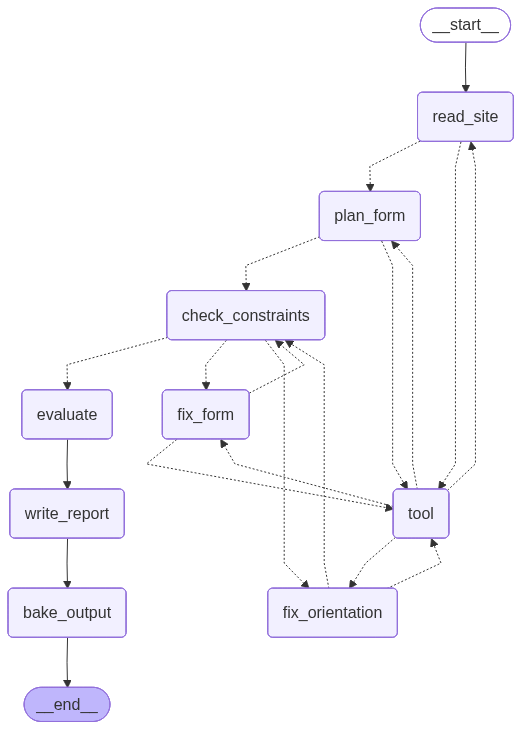

In [30]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import importlib

# Reload all changed modules so the kernel picks up the new graph without restart
import nodes.tools  as _tools_mod;  importlib.reload(_tools_mod)
import nodes.reason as _reason_mod; importlib.reload(_reason_mod)
import graph        as _graph_mod;  importlib.reload(_graph_mod)
from graph import build_graph
from IPython.display import display, Image

@dataclass
class NotebookContext:
    llm: Any
    mcp_client: MockMcpClient
    tools: list[dict]
    layout_data: dict
    max_iterations: int
    edited_layout_path: Path

# Build a context using mock client + override LLM (no API call yet)
mock_client = MockMcpClient()
mock_client.initialize()
tools = mock_client.list_tools()

nb_ctx = NotebookContext(
    llm=build_llm_from_override(tools_schema=tools),
    mcp_client=mock_client,
    tools=tools,
    layout_data={},
    max_iterations=LLM_OVERRIDE["max_iterations"],
    edited_layout_path=PYTHON_DIR.parent / "team_04_edited_layout.json",
)

# Compile the 9-node graph
app = build_graph(nb_ctx)
print("Graph compiled ✅")

g = app.get_graph()
print(f"\nNodes ({len(g.nodes)}): {[n for n in g.nodes]}")
print(f"\nEdges ({len(g.edges)}):")
for e in g.edges:
    print(f"  {e.source:20s} → {e.target}")

# ── Render LangGraph Mermaid PNG ──────────────────────────────────────────────
print("\nRendering graph diagram …")
try:
    png_bytes = g.draw_mermaid_png()
    display(Image(png_bytes))
except Exception as e:
    print(f"PNG render failed ({e}), falling back to ASCII:")
    try:
        g.print_ascii()
    except ImportError:
        print("(install grandalf for ASCII rendering)")


── LangGraph execution graph (Mermaid PNG) ──


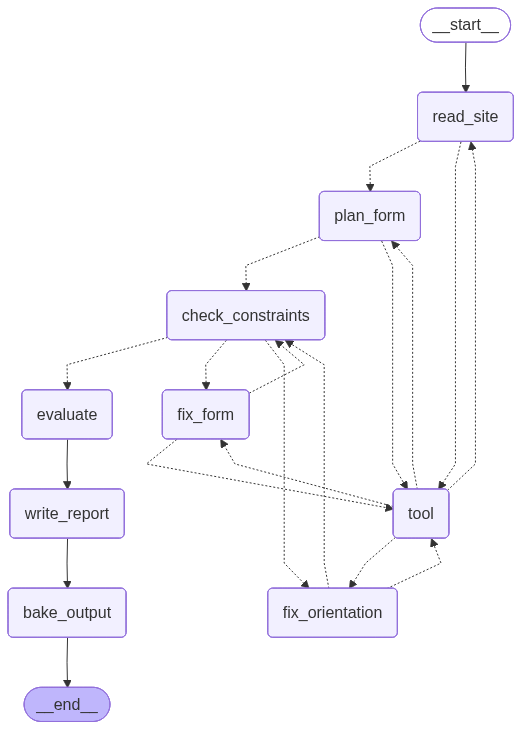

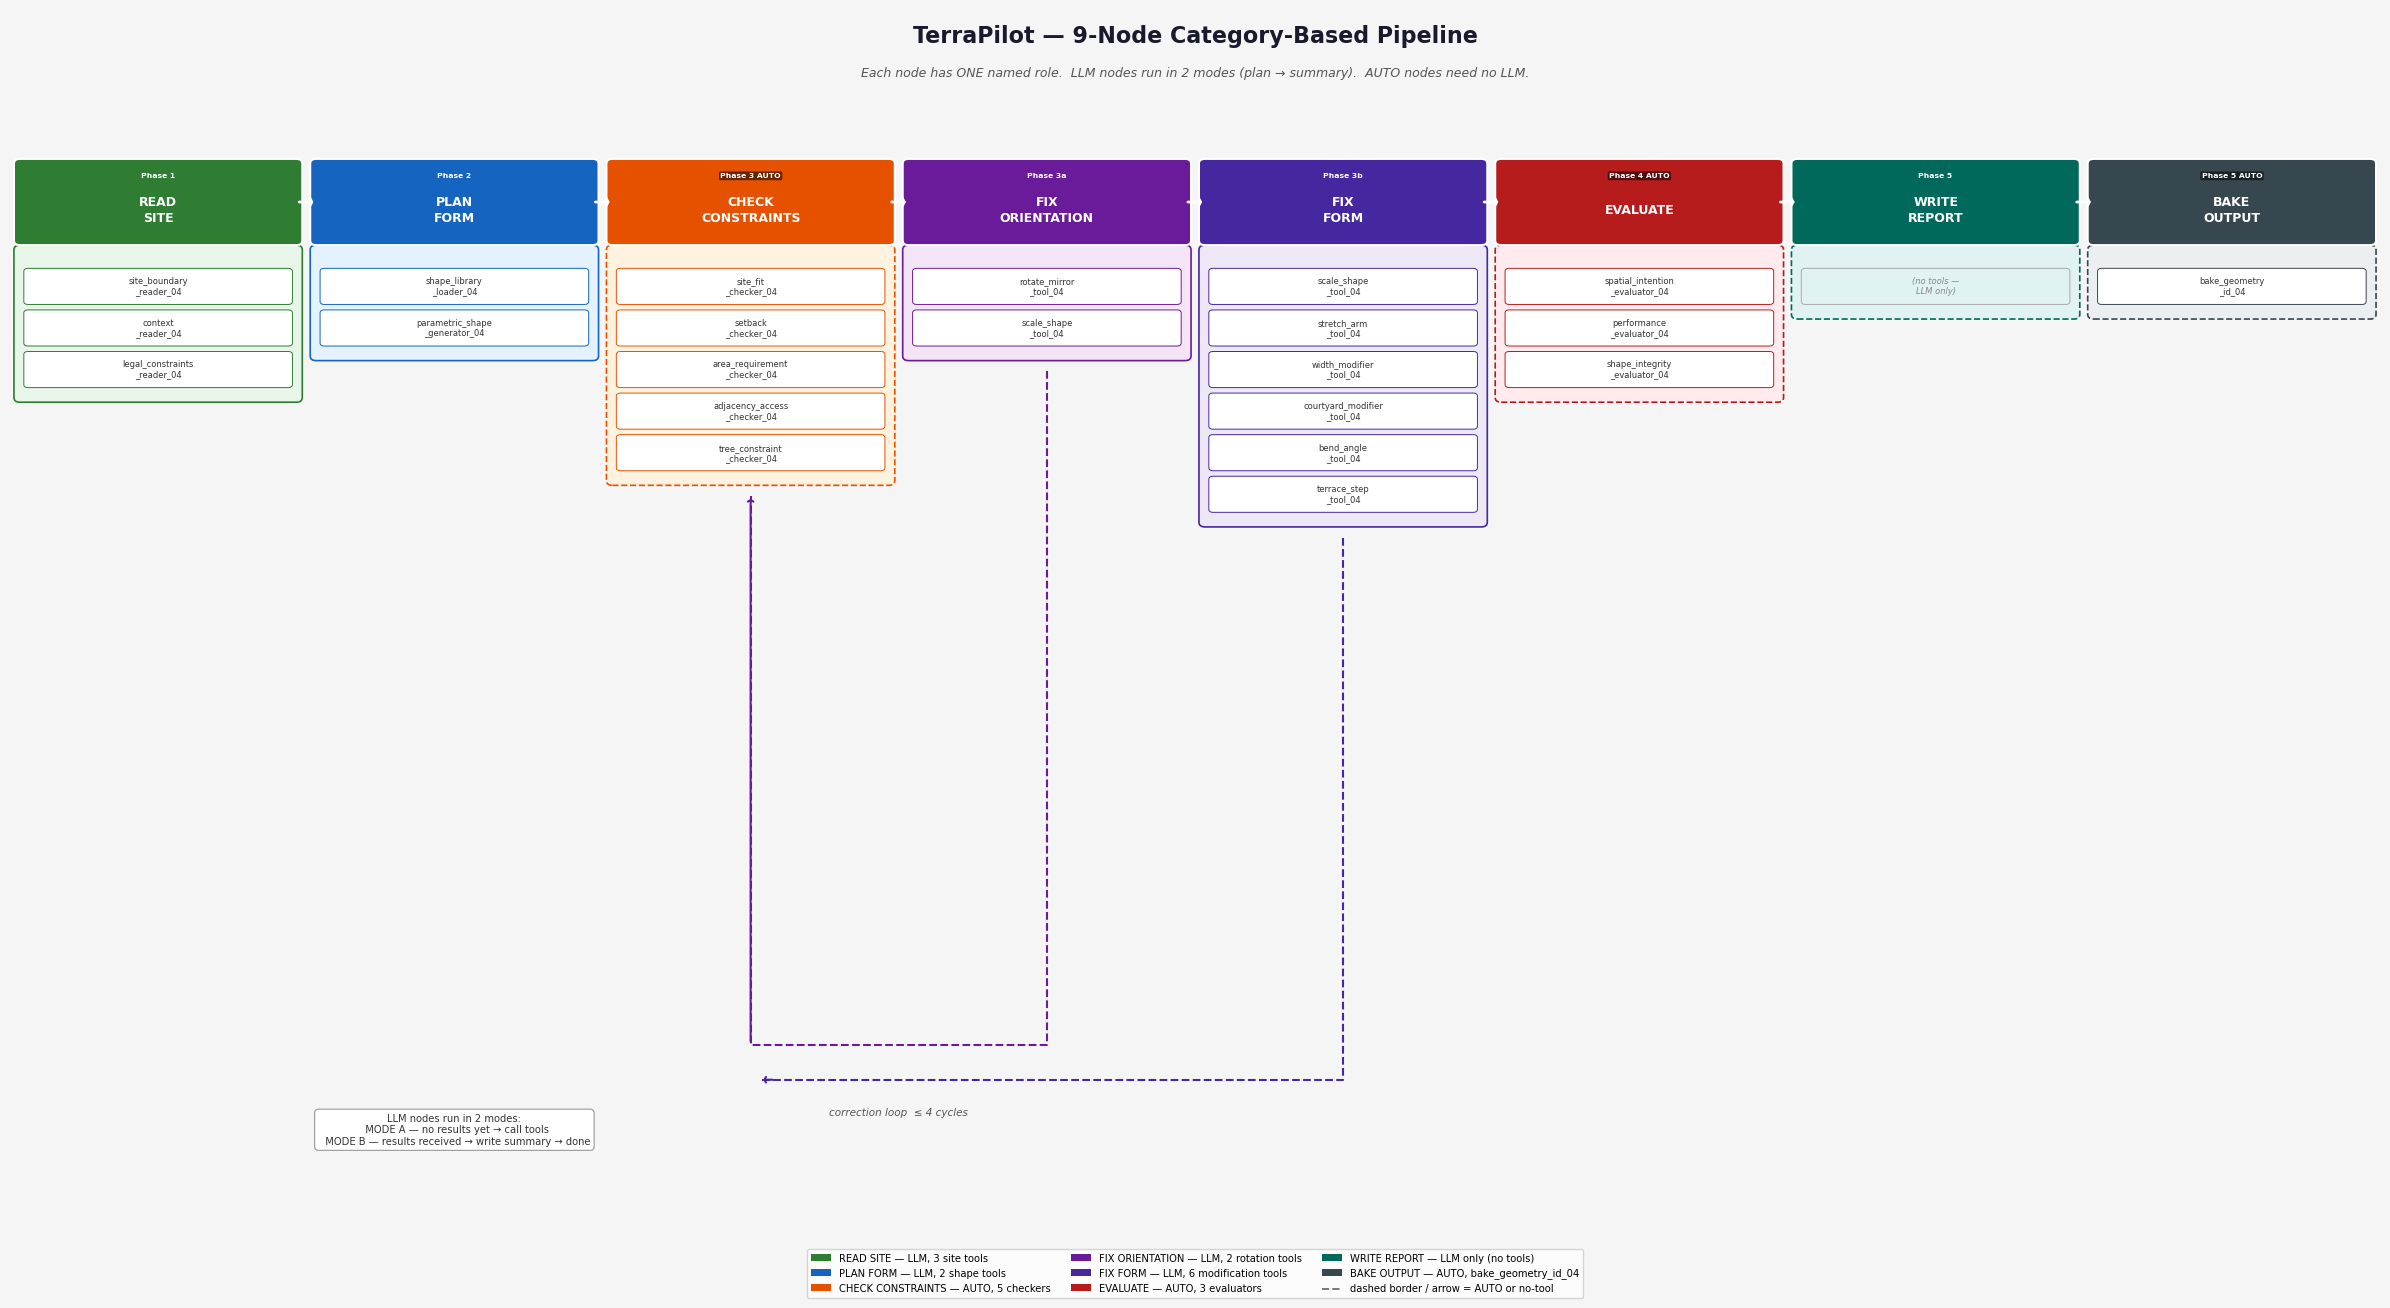

Saved → C:\Users\Chloe\Documents\GitHub\AIA26_Studio\team_04\python\terrapilot_workflow.png


In [31]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

# Reload and re-render with the latest graph.py
import graph as _graph_mod; importlib.reload(_graph_mod)
from graph import build_graph

print("── LangGraph execution graph (Mermaid PNG) ──")
_app2 = build_graph(nb_ctx)
try:
    from IPython.display import display, Image
    display(Image(_app2.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG render failed: {e}")
    try:
        _app2.get_graph().print_ascii()
    except ImportError:
        g2 = _app2.get_graph()
        print("Nodes:", list(g2.nodes))
        print("Edges:", [(ed.source, ed.target) for ed in g2.edges])

# ── 9-Node Category Pipeline — matplotlib diagram ─────────────────────────────
# Node order: read_site → plan_form → check_constraints → fix_orientation
#             → fix_form → evaluate → write_report → bake_output
# Plus: tool (shared, shown separately)

NODES = [
    {
        "label":  "READ\nSITE",
        "node":   "read_site",
        "kind":   "llm",
        "color":  "#2E7D32", "light": "#E8F5E9",
        "phase":  "Phase 1",
        "tools":  ["site_boundary\n_reader_04",
                   "context\n_reader_04",
                   "legal_constraints\n_reader_04"],
    },
    {
        "label":  "PLAN\nFORM",
        "node":   "plan_form",
        "kind":   "llm",
        "color":  "#1565C0", "light": "#E3F2FD",
        "phase":  "Phase 2",
        "tools":  ["shape_library\n_loader_04",
                   "parametric_shape\n_generator_04"],
    },
    {
        "label":  "CHECK\nCONSTRAINTS",
        "node":   "check_constraints",
        "kind":   "auto",
        "color":  "#E65100", "light": "#FFF3E0",
        "phase":  "Phase 3 AUTO",
        "tools":  ["site_fit\n_checker_04",
                   "setback\n_checker_04",
                   "area_requirement\n_checker_04",
                   "adjacency_access\n_checker_04",
                   "tree_constraint\n_checker_04"],
    },
    {
        "label":  "FIX\nORIENTATION",
        "node":   "fix_orientation",
        "kind":   "llm",
        "color":  "#6A1B9A", "light": "#F3E5F5",
        "phase":  "Phase 3a",
        "tools":  ["rotate_mirror\n_tool_04",
                   "scale_shape\n_tool_04"],
    },
    {
        "label":  "FIX\nFORM",
        "node":   "fix_form",
        "kind":   "llm",
        "color":  "#4527A0", "light": "#EDE7F6",
        "phase":  "Phase 3b",
        "tools":  ["scale_shape\n_tool_04",
                   "stretch_arm\n_tool_04",
                   "width_modifier\n_tool_04",
                   "courtyard_modifier\n_tool_04",
                   "bend_angle\n_tool_04",
                   "terrace_step\n_tool_04"],
    },
    {
        "label":  "EVALUATE",
        "node":   "evaluate",
        "kind":   "auto",
        "color":  "#B71C1C", "light": "#FFEBEE",
        "phase":  "Phase 4 AUTO",
        "tools":  ["spatial_intention\n_evaluator_04",
                   "performance\n_evaluator_04",
                   "shape_integrity\n_evaluator_04"],
    },
    {
        "label":  "WRITE\nREPORT",
        "node":   "write_report",
        "kind":   "llm",
        "color":  "#00695C", "light": "#E0F2F1",
        "phase":  "Phase 5",
        "tools":  ["(no tools —\nLLM only)"],
    },
    {
        "label":  "BAKE\nOUTPUT",
        "node":   "bake_output",
        "kind":   "auto",
        "color":  "#37474F", "light": "#ECEFF1",
        "phase":  "Phase 5 AUTO",
        "tools":  ["bake_geometry\n_id_04"],
    },
]

n_cols = len(NODES)
fig_w  = 24
col_w  = fig_w / n_cols
row_h  = 0.54
top_y  = 11.0
hdr_h  = 1.0
tool_y0 = top_y - hdr_h - 0.12

fig, ax = plt.subplots(figsize=(fig_w, 13))
ax.set_xlim(0, fig_w)
ax.set_ylim(-2.0, 13.0)
ax.axis("off")
ax.set_facecolor("#F5F5F5")
fig.patch.set_facecolor("#F5F5F5")

# ── Title ──────────────────────────────────────────────────────────────────────
ax.text(fig_w / 2, 12.65,
        "TerraPilot — 9-Node Category-Based Pipeline",
        ha="center", va="center", fontsize=16, fontweight="bold", color="#1A1A2E")
ax.text(fig_w / 2, 12.18,
        "Each node has ONE named role.  LLM nodes run in 2 modes (plan → summary).  AUTO nodes need no LLM.",
        ha="center", va="center", fontsize=9, color="#555", style="italic")

# ── Phase node columns ─────────────────────────────────────────────────────────
for ci, nd in enumerate(NODES):
    x0   = ci * col_w + 0.10
    mid  = x0 + (col_w - 0.20) / 2
    c    = nd["color"]
    lc   = nd["light"]
    auto = nd["kind"] == "auto"
    no_tools = nd["tools"] == ["(no tools —\nLLM only)"]

    # ── Header ─────────────────────────────────────────────────────────────
    hdr = FancyBboxPatch((x0, top_y - hdr_h), col_w - 0.20, hdr_h,
                         boxstyle="round,pad=0.06", fc=c, ec="white", lw=1.5, zorder=3)
    ax.add_patch(hdr)

    # Phase tag (small, top of header)
    ax.text(mid, top_y - 0.16, nd["phase"],
            ha="center", va="center", fontsize=5.5, color="white",
            fontweight="bold", zorder=5,
            bbox=dict(fc="black" if auto else c, ec="none",
                      boxstyle="round,pad=0.18", alpha=0.40 if not auto else 0.55))

    # Node name label (bottom of header)
    ax.text(mid, top_y - hdr_h / 2 - 0.10, nd["label"],
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="white", zorder=4, linespacing=1.3)

    # node id (tiny italic)
    ax.text(mid, top_y - hdr_h + 0.14, nd["node"],
            ha="center", va="center", fontsize=5.0, color=c,
            style="italic", zorder=4)

    # ── Tool boxes ─────────────────────────────────────────────────────────
    col_h = len(nd["tools"]) * row_h + 0.30
    bg = FancyBboxPatch((x0, tool_y0 - col_h), col_w - 0.20, col_h,
                        boxstyle="round,pad=0.06", fc=lc, ec=c, lw=1.2, zorder=2,
                        linestyle="dashed" if (auto or no_tools) else "solid")
    ax.add_patch(bg)

    for ti, tlabel in enumerate(nd["tools"]):
        ty  = tool_y0 - 0.26 - ti * row_h
        bx  = FancyBboxPatch((x0 + 0.08, ty - row_h * 0.76),
                             col_w - 0.36, row_h * 0.72,
                             boxstyle="round,pad=0.04",
                             fc="white" if not no_tools else lc,
                             ec=c if not no_tools else "#aaa",
                             lw=0.7, zorder=4)
        ax.add_patch(bx)
        ax.text(mid, ty - row_h * 0.40, tlabel,
                ha="center", va="center", fontsize=6.0,
                color="#333" if not no_tools else "#888",
                zorder=5, linespacing=1.15, style="italic" if no_tools else "normal")

# ── Sequential flow arrows (left → right, top row) ────────────────────────────
for ci in range(n_cols - 1):
    x_arr = (ci + 1) * col_w
    ax.annotate("",
                xy=(x_arr + 0.10, top_y - hdr_h / 2),
                xytext=(x_arr - 0.10, top_y - hdr_h / 2),
                arrowprops=dict(arrowstyle="->,head_width=0.26,head_length=0.13",
                                color="white", lw=2.0),
                zorder=6)

# ── Correction loop: fix_orientation & fix_form → back to check_constraints ───
ci_chk    = next(i for i, n in enumerate(NODES) if n["node"] == "check_constraints")
ci_orient = next(i for i, n in enumerate(NODES) if n["node"] == "fix_orientation")
ci_form   = next(i for i, n in enumerate(NODES) if n["node"] == "fix_form")

x_chk    = (ci_chk    + 0.5) * col_w
x_orient = (ci_orient + 0.5) * col_w
x_form   = (ci_form   + 0.5) * col_w

def _tool_bottom(ci):
    return tool_y0 - len(NODES[ci]["tools"]) * row_h - 0.50

loop_y1 = -0.45
loop_y2 = -0.90

# orient loop (higher arc)
ax.plot([x_orient, x_orient, x_chk, x_chk],
        [_tool_bottom(ci_orient), loop_y1, loop_y1, _tool_bottom(ci_chk)],
        color=NODES[ci_orient]["color"], lw=1.5, ls="--", zorder=3)
ax.annotate("",
            xy=(x_chk, _tool_bottom(ci_chk)),
            xytext=(x_chk, loop_y1 + 0.01),
            arrowprops=dict(arrowstyle="->,head_width=0.20,head_length=0.11",
                            color=NODES[ci_orient]["color"], lw=1.5),
            zorder=4)

# form loop (lower arc)
ax.plot([x_form, x_form, x_chk + 0.10],
        [_tool_bottom(ci_form), loop_y2, loop_y2],
        color=NODES[ci_form]["color"], lw=1.5, ls="--", zorder=3)
ax.annotate("",
            xy=(x_chk + 0.10, loop_y2),
            xytext=(x_chk + 0.25, loop_y2),
            arrowprops=dict(arrowstyle="->,head_width=0.20,head_length=0.11",
                            color=NODES[ci_form]["color"], lw=1.5),
            zorder=4)

ax.text((x_orient + x_chk) / 2, loop_y2 - 0.42,
        "correction loop  ≤ 4 cycles",
        ha="center", va="center", fontsize=7.5, color="#555", style="italic")

# ── Two-mode callout ──────────────────────────────────────────────────────────
ax.text(1.5 * col_w, -1.55,
        "LLM nodes run in 2 modes:\n"
        "  MODE A — no results yet → call tools\n"
        "  MODE B — results received → write summary → done",
        ha="center", va="center", fontsize=7.2, color="#333",
        bbox=dict(fc="white", ec="#999", boxstyle="round,pad=0.4", lw=0.8))

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(fc="#2E7D32", label="READ SITE — LLM, 3 site tools"),
    mpatches.Patch(fc="#1565C0", label="PLAN FORM — LLM, 2 shape tools"),
    mpatches.Patch(fc="#E65100", label="CHECK CONSTRAINTS — AUTO, 5 checkers"),
    mpatches.Patch(fc="#6A1B9A", label="FIX ORIENTATION — LLM, 2 rotation tools"),
    mpatches.Patch(fc="#4527A0", label="FIX FORM — LLM, 6 modification tools"),
    mpatches.Patch(fc="#B71C1C", label="EVALUATE — AUTO, 3 evaluators"),
    mpatches.Patch(fc="#00695C", label="WRITE REPORT — LLM only (no tools)"),
    mpatches.Patch(fc="#37474F", label="BAKE OUTPUT — AUTO, bake_geometry_id_04"),
    Line2D([0], [0], color="#777", lw=1.4, ls="--", label="dashed border / arrow = AUTO or no-tool"),
]
ax.legend(handles=legend_items, loc="lower center", ncol=3,
          bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=7.2,
          edgecolor="#CCC", facecolor="white")

plt.tight_layout()
out_path = PYTHON_DIR / "terrapilot_workflow.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


## 6 · Test Cases <a id="6"></a>
Pick `ACTIVE_TEST` to switch scenarios.  
Each test pre-populates a user prompt + optional mock overrides.

In [32]:
TEST_CASES = {

    # ── 1. Simple bar on rectangle ──────────────────────────────────────────
    "simple_bar": {
        "description": "Rectangular site, simple bar building, no special constraints.",
        "prompt": (
            "I have a rectangular site 100m × 80m. "
            "Create a bar-shaped building that meets a 4000 sqm GFA requirement, "
            "with 5m setbacks on all sides and 4 floors."
        ),
        "mock_overrides": {},   # no overrides — use default stubs
    },

    # ── 2. Pentagon site with trees (from slides) ───────────────────────────
    "pentagon_trees": {
        "description": "Pentagon site ~50 000 sqm, 80 protected trees, courtyard typology.",
        "prompt": (
            "Site is a pentagon with area 50 000 sqm and 80 protected trees (radius 5m each). "
            "Design a courtyard building with at least 25 000 sqm GFA. "
            "Avoid all trees, align with the north view, and explain your decisions."
        ),
        "mock_overrides": {
            # Override tree checker to force a conflict on first try → agent must rotate
            "tree_constraint_checker_04": lambda args: json.dumps({
                "success": True,
                "data": {
                    "no_conflicts": False,
                    "conflicting_trees": [12, 34, 56],
                    "nearest_tree_distance_m": 1.2,
                },
                "metadata": {"tool_name": "tree_constraint_checker_04", "placeholder": True},
            }),
        },
    },

    # ── 3. Slope adaptation ─────────────────────────────────────────────────
    "sloped_site": {
        "description": "Sloped site requiring terrace/step adaptation.",
        "prompt": (
            "The site has a 15-degree slope from north to south, area 6000 sqm. "
            "Create an L-shaped building that adapts to the slope using terracing. "
            "Ensure good solar exposure on the south facade."
        ),
        "mock_overrides": {
            "performance_evaluator_04": lambda args: json.dumps({
                "success": True,
                "data": {
                    "sun_hours_avg": 7.2,
                    "slope_adaptation_score": 0.91,
                    "open_space_percentage": 38,
                    "access_score": 0.88,
                    "area_efficiency_ratio": 0.81,
                    "overall_performance_score": 0.87,
                },
                "metadata": {"tool_name": "performance_evaluator_04", "placeholder": True},
            }),
        },
    },

    # ── 4. GFA deficit — agent must iterate ─────────────────────────────────
    "gfa_deficit": {
        "description": "Area requirements not met on first attempt; agent must scale up.",
        "prompt": (
            "Site is 8000 sqm rectangle. I need 10 000 sqm GFA minimum, "
            "max 45% site coverage, 6 floors max. "
            "Start with a U-shape and iterate until the area is met."
        ),
        "mock_overrides": {
            # First check fails, second passes (simulate two iterations)
            "_area_call_count": [0],
            "area_requirement_checker_04": None,  # patched dynamically below
        },
    },

    # ── 5. Irregular boundary ───────────────────────────────────────────────
    "irregular_boundary": {
        "description": "Irregular hexagonal site; building needs to bend to fit.",
        "prompt": (
            "The site is an irregular hexagon with a sharp north-east corner. "
            "Create an L-shaped building that responds to the irregular boundary "
            "by bending the north wing 20 degrees. Validate all setbacks."
        ),
        "mock_overrides": {
            "setback_checker_04": lambda args: json.dumps({
                "success": True,
                "data": {"compliant": True, "violations": [], "min_clearance_m": 5.1},
                "metadata": {"tool_name": "setback_checker_04", "placeholder": True},
            }),
        },
    },
}

# ── PICK YOUR TEST CASE ──────────────────────────────────────────────────────
ACTIVE_TEST = "simple_bar"   # ← change this to try different cases

tc = TEST_CASES[ACTIVE_TEST]
print(f"Active test  : {ACTIVE_TEST}")
print(f"Description  : {tc['description']}")
print(f"\nPrompt:\n  {tc['prompt']}")

Active test  : simple_bar
Description  : Rectangular site, simple bar building, no special constraints.

Prompt:
  I have a rectangular site 100m × 80m. Create a bar-shaped building that meets a 4000 sqm GFA requirement, with 5m setbacks on all sides and 4 floors.


## 7 · Full Agent Run <a id="7"></a>
Wire the mock client and LLM into the graph and run the selected test case end-to-end.  
**Requires a valid API key in `LLM_OVERRIDE`.**

In [42]:
import importlib

# Force-reload _runtime.llm so the schema fix (no strict, optional args) takes effect
import _runtime.llm as _llm_mod
importlib.reload(_llm_mod)

# Force-reload nodes.reason so it picks up the updated call_llm signature
import nodes.reason as _reason_mod
importlib.reload(_reason_mod)

# Force-reload graph so the print_ascii fix takes effect
import graph as _graph_mod
importlib.reload(_graph_mod)
from graph import run_agent

# Allow enough iterations and time for a full design workflow
LLM_OVERRIDE["max_iterations"] = 20
LLM_OVERRIDE["timeout_seconds"] = 300   # 5 min — history grows after each tool call

# ── Build client with any per-test overrides applied ─────────────────────────
tc = TEST_CASES[ACTIVE_TEST]
run_client = MockMcpClient()
run_client.initialize()
# Patch overrides into the client's response dict
for tool_name, stub in tc.get("mock_overrides", {}).items():
    if not tool_name.startswith("_") and stub is not None:
        MOCK_TOOL_RESPONSES[tool_name] = stub

# ── Build context ─────────────────────────────────────────────────────────────
run_ctx = NotebookContext(
    llm=build_llm_from_override(tools_schema=run_client.list_tools()),
    mcp_client=run_client,
    tools=run_client.list_tools(),
    layout_data={},
    max_iterations=LLM_OVERRIDE["max_iterations"],
    edited_layout_path=PYTHON_DIR.parent / "team_04_edited_layout.json",
)

# ── Run ───────────────────────────────────────────────────────────────────────
print(f"Running test: {ACTIVE_TEST}")
print(f"Prompt      : {tc['prompt'][:80]}...\n")
print("─" * 64)

response = run_agent(tc["prompt"], run_ctx)

print("─" * 64)
print("\nFINAL RESPONSE:\n")
print(response)

# ── Tool call trace ───────────────────────────────────────────────────────────
calls = run_client.call_history()
if calls:
    print(f"\n\nTool calls made ({len(calls)}):")
    for i, c in enumerate(calls, 1):
        print(f"  {i:2d}. {c['tool']}")
        if c["args"]:
            for k, v in c["args"].items():
                print(f"        {k}: {v}")


🟢 MockMcpClient initialized (no Grasshopper needed)
LLM built → provider=cloudflare  model=@cf/meta/llama-3.3-70b-instruct-fp8-fast
Running test: simple_bar
Prompt      : I have a rectangular site 100m × 80m. Create a bar-shaped building that meets a ...

────────────────────────────────────────────────────────────────

[site] calling LLM â€¦
Calling tool: site_boundary_reader_04 with arguments: {'polygon_coordinates': [[0, 0], [100, 0], [100, 80], [0, 80], [0, 0]], 'site_area_sqm': 8000, 'number_of_trees': 0, 'tree_radius_m': 5}
  🔧 MOCK site_boundary_reader_04
Tool result: {"success": true, "data": {"site_boundary_curve": "mock-site-guid", "site_area_sqm": 8000, "site_centroid": [0, 0], "bounding_box": {"min": [-100, -80], "max": [100, 80]}, "perimeter_m": 600, "number_of_sides": 5, "tree_locations": [], "usable_area_sqm": 7440.0}, "metadata": {"tool_name": "site_boundary_reader_04", "placeholder": true}}
Calling tool: context_reader_04 with arguments: {'roads': [], 'neighboring_buil

c:\Users\Chloe\miniconda3\envs\311\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value={'action': 'final', 'fina...nd height constraints.'}, input_type=dict])
  return self.__pydantic_serializer__.to_python(


  🔧 MOCK site_fit_checker_04
  🔧 MOCK setback_checker_04
  🔧 MOCK area_requirement_checker_04
  🔧 MOCK adjacency_access_checker_04
  🔧 MOCK tree_constraint_checker_04
[check_constraints] cycle=1  violations=[]
  🔧 MOCK spatial_intention_evaluator_04
  🔧 MOCK performance_evaluator_04
  🔧 MOCK shape_integrity_evaluator_04
[evaluate] All 3 evaluators complete.

[report] calling LLM â€¦
[llm] Non-JSON response — treating as plain-text final_response
  🔧 MOCK bake_geometry_id_04
[bake_output] Baked â†’ Rhino GUID: baked-4eadb570

Workflow graph:
                                                                           +-----------+                                                                     
                                                                           | __start__ |                                                                     
                                                                           +-----------+                                                 